# eBay Tech Deals – Exploratory Data Analysis
This notebook analyzes the cleaned dataset generated from the scraping pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("cleaned_ebay_deals.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,timestamp,title,price,original_price,shipping,item_url,discount_percentage
0,2026-03-10 12:56:04,"Sony Xperia 10 IV 5G XQ-CC54 128GB 6.0"" Androi...",171.58,171.58,Free shipping,https://www.ebay.com/itm/197837525392?_trkparm...,0.0
1,2026-03-10 12:56:04,Nokia 1209 - Midnight Blue (Unlocked) Cellular...,36.97,NaN,Free shipping,https://www.ebay.com/itm/167612398310?_trkparm...,NaN
2,2026-03-10 12:56:04,Cartine Rizla Liquorice Corte – Gusto Naturale...,35.94,35.94,Free shipping,https://www.ebay.com/itm/364382641988?_trkparm...,0.0
3,2026-03-10 12:56:04,Honor Magic V 5G 512GB Google Android 12 Snapd...,540.76,540.76,Free shipping,https://www.ebay.com/itm/406378990824?_trkparm...,0.0
4,2026-03-10 12:56:04,NaN,NaN,NaN,Shipping info unavailable,https://www.ebay.com/globaldeals/tech/cell-pho...,NaN


## Time Series Analysis – Deals per Hour

In [2]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df["hour"] = df["timestamp"].dt.hour

deals_per_hour = df.groupby("hour").size()
deals_per_hour

hour
11    117
12     80
14     80
dtype: int64

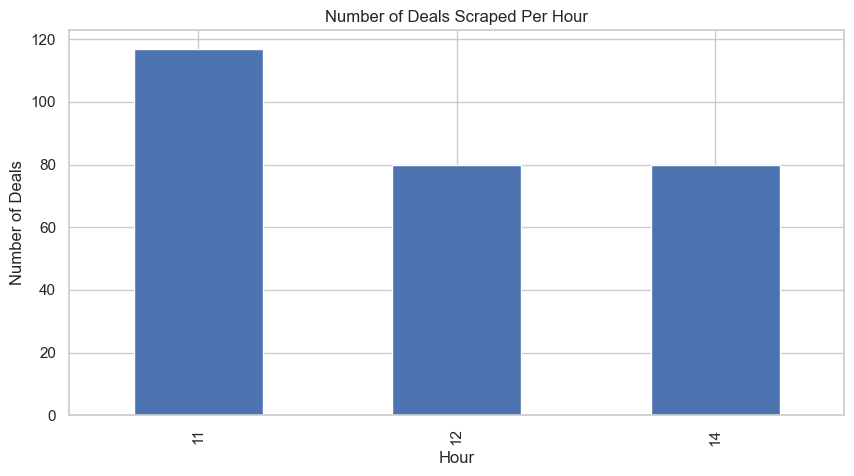

In [3]:
plt.figure(figsize=(10, 5))
deals_per_hour.plot(kind="bar")

plt.title("Number of Deals Scraped Per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Deals")

plt.show()

## Price Distribution Analysis

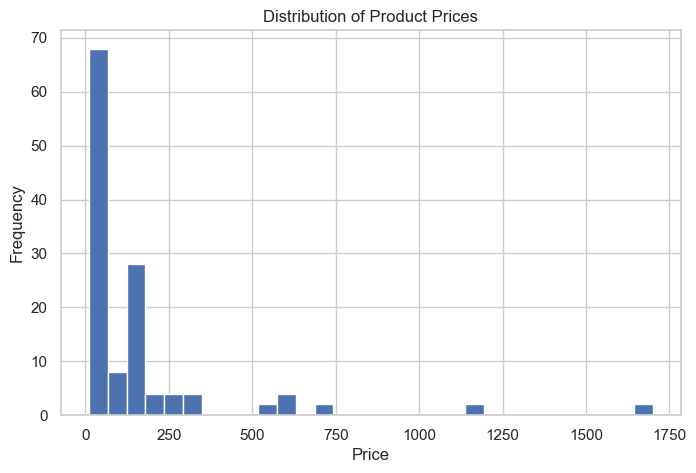

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=30)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

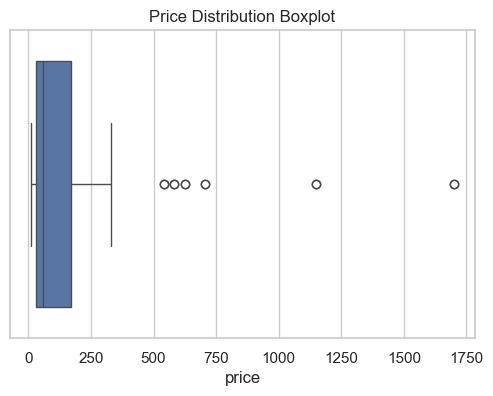

In [5]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["price"])

plt.title("Price Distribution Boxplot")
plt.show()

## Original Price vs Discounted Price

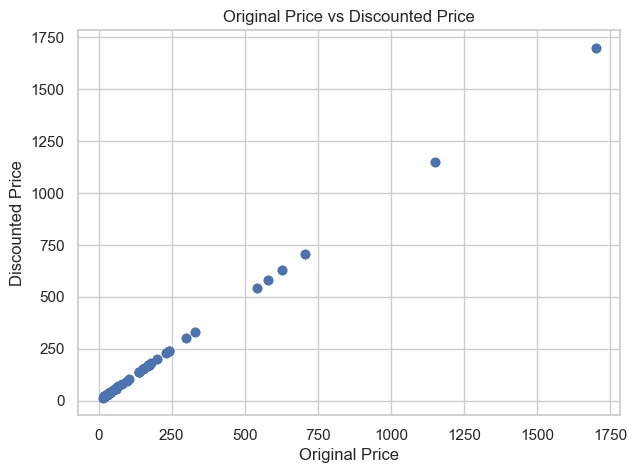

In [6]:
plt.figure(figsize=(7, 5))

plt.scatter(df["original_price"], df["price"])

plt.xlabel("Original Price")
plt.ylabel("Discounted Price")
plt.title("Original Price vs Discounted Price")

plt.show()

## Discount Percentage Distribution

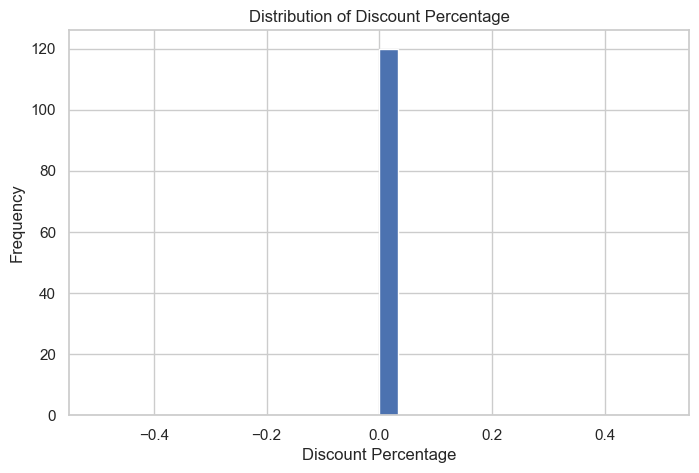

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["discount_percentage"].dropna(), bins=30)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")

plt.show()

## Shipping Information Analysis

In [8]:
shipping_counts = df["shipping"].value_counts()
shipping_counts

shipping
Shipping info unavailable    166
Free shipping                111
Name: count, dtype: int64

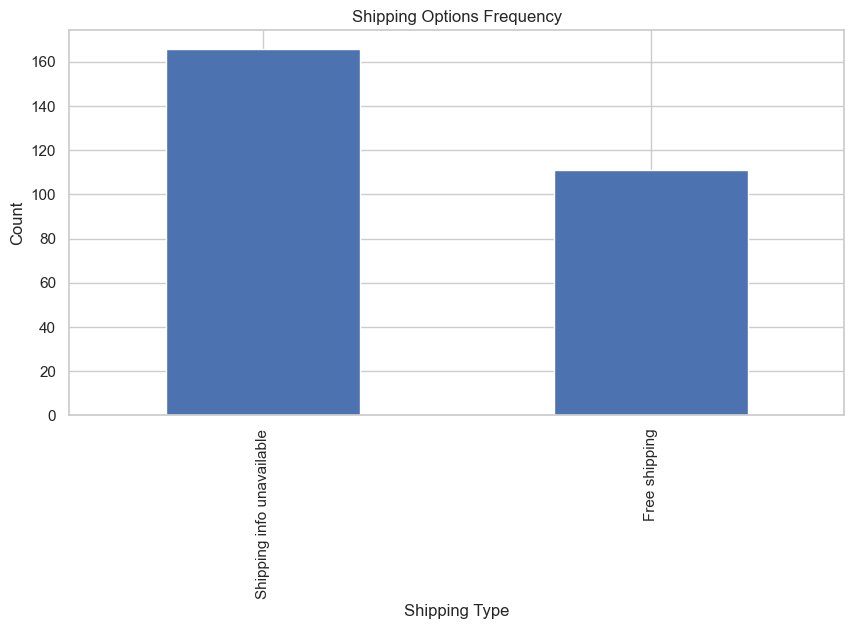

In [9]:
plt.figure(figsize=(10, 5))

shipping_counts.plot(kind="bar")

plt.title("Shipping Options Frequency")
plt.xlabel("Shipping Type")
plt.ylabel("Count")

plt.show()

## Keyword Analysis in Product Titles

In [10]:
keywords = ["Apple", "Samsung", "Laptop", "iPhone", "Tablet", "Gimbal"]

keyword_counts = {}

for keyword in keywords:
    keyword_counts[keyword] = (
        df["title"].str.contains(keyword, case=False, na=False).sum()
    )

keyword_counts

{'Apple': np.int64(37),
 'Samsung': np.int64(14),
 'Laptop': np.int64(7),
 'iPhone': np.int64(22),
 'Tablet': np.int64(6),
 'Gimbal': np.int64(0)}

In [11]:
keyword_df = pd.DataFrame(keyword_counts.items(), columns=["Keyword", "Count"])
keyword_df

,Keyword,Count
0,Apple,37
1,Samsung,14
2,Laptop,7
3,iPhone,22
4,Tablet,6
5,Gimbal,0


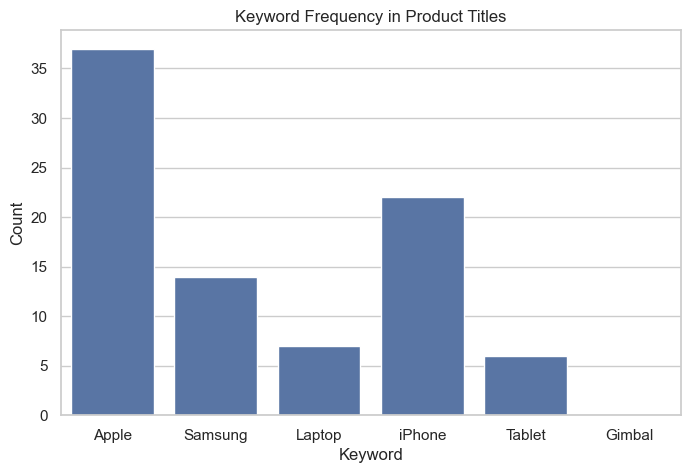

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(data=keyword_df, x="Keyword", y="Count")

plt.title("Keyword Frequency in Product Titles")

plt.show()

## Price Difference Analysis

In [13]:
df["price_difference"] = df["original_price"] - df["price"]
df[["price_difference"]].head()

,price_difference
138,NaN
84,NaN
83,NaN
82,NaN
81,NaN


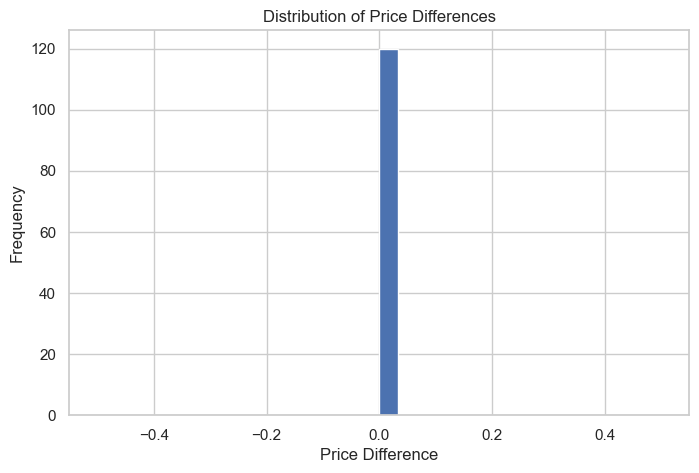

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(df["price_difference"].dropna(), bins=30)

plt.title("Distribution of Price Differences")
plt.xlabel("Price Difference")
plt.ylabel("Frequency")

plt.show()

## Top 5 Deals with Highest Discounts

In [15]:
top_deals = df.sort_values("discount_percentage", ascending=False).head(5)

top_deals[["title", "price", "original_price", "discount_percentage"]]

,title,price,original_price,discount_percentage
0,"Sony Xperia 10 IV 5G XQ-CC54 128GB 6.0"" Androi...",171.58,171.58,0.0
78,PSU Dell Force10 300W F2R Normal Flow 48V DC N...,139.12,139.12,0.0
22,🔥UPGRADED TITAN CLOCKMAN🔥TOILET TOWER DEFENSE ...,13.38,13.38,0.0
23,"NGC - Mario Party 5 - (OVP, mit Anleitung)",57.91,57.91,0.0
25,Case RIMOWA For iPhone 17 Pro - Aluminium!,150.71,150.71,0.0
